# Conversion Analysis

## Objective

Analyze website session conversion to understand how effectively
different acquisition sources convert website traffic into orders.

## Key Questions

1. Which acquisition sources generate the most sessions?
2. Which acquisition sources have the highest conversion rates?
3. Is conversion associated with acquisition source?
4. Is device type associated with conversion rates



## 1. Load and Prepare Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#Loading data
session_conversion = pd.read_csv('../data/processed/session_conversion.csv')

In [4]:
#Inspecting the first few rows of the dataset
session_conversion.head()

,website_session_id,user_id,created_at,utm_source,utm_campaign,utm_content,device_type,is_repeat_session,converted
0,2056,1267,2012-04-02 12:49:36 UTC,NaN,NaN,NaN,desktop,1,0
1,6124,3264,2012-05-04 16:42:19 UTC,NaN,NaN,NaN,desktop,1,0
2,6165,1794,2012-05-05 06:17:59 UTC,NaN,NaN,NaN,desktop,1,0
3,6591,1902,2012-05-09 12:18:45 UTC,NaN,NaN,NaN,desktop,1,0
4,6902,3875,2012-05-11 16:13:58 UTC,NaN,NaN,NaN,desktop,1,0


In [5]:
session_conversion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   user_id             472871 non-null  int64 
 2   created_at          472871 non-null  object
 3   utm_source          389543 non-null  object
 4   utm_campaign        389543 non-null  object
 5   utm_content         389543 non-null  object
 6   device_type         472871 non-null  object
 7   is_repeat_session   472871 non-null  int64 
 8   converted           472871 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 32.5+ MB


In [6]:
#Checking the percentage of null values compared to total records
session_conversion.isnull().sum() / len(session_conversion) * 100

website_session_id     0.000000
user_id                0.000000
created_at             0.000000
utm_source            17.621719
utm_campaign          17.621719
utm_content           17.621719
device_type            0.000000
is_repeat_session      0.000000
converted              0.000000
dtype: float64

> We can see that the percentage of null values in utm_source,utm_campaign,utm_content is approx 17.6 percent which is very high hence we cannot remove the rows.

## Is conversion associated with acquisition source?

Our objective is to check whether the utm_source and conversion are independent of each other or not. In this case chi square test for independence will be best choice
> Null hypothesis: conversion and UTM_source are independent
> Alternate hypothesis: conversion and UTM_source are not independent
> Significance level: We will keep alpha at 0.05
* We will be excluding the null values from this analysis since we do not have info on their UTM source and since the data percentage of missing values is too high it would be unreliable to completely delete those rows and imputing them with mode will introduce bias in the analysis.



In [7]:
source_df = session_conversion[session_conversion['utm_source'].notna()]

In [8]:
#Importing chi2_contingency from scipy.stats
from scipy.stats import chi2_contingency

In [9]:
pd.crosstab(source_df['utm_source'], source_df['converted'])

converted,0,1
utm_source,,
bsearch,58304,4519
gsearch,294702,21333
socialbook,10342,343


<Axes: xlabel='utm_source', ylabel='count'>

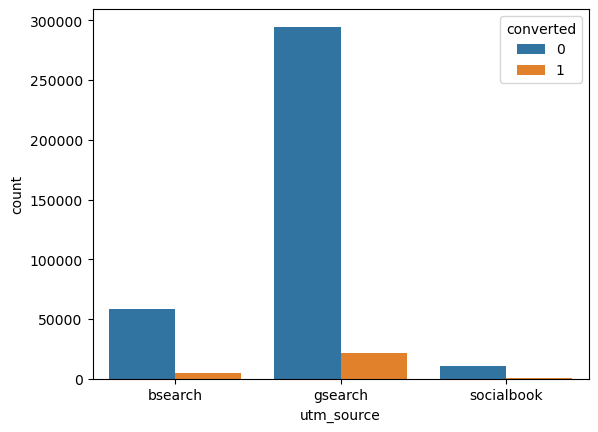

In [10]:
sns.countplot(data = source_df,x = 'utm_source',hue = 'converted')

* It seems that gsearch brings the highest traffic and also has the highest number of conversions however just by looking at the graph it is not clear if the conversion rates are same or different which will be cleared by performing the hypothesis testing.

In [11]:
chi2_contingency(pd.crosstab(source_df['utm_source'], source_df['converted']))

Chi2ContingencyResult(statistic=np.float64(232.73750897190575), pvalue=np.float64(2.8952899363727394e-51), dof=2, expected_freq=array([[ 58598.43818012,   4224.56181988],
       [294783.07960867,  21251.92039133],
       [  9966.48221121,    718.51778879]]))

In [12]:
pvalue = chi2_contingency(pd.crosstab(source_df['utm_source'], source_df['converted']))[1]

In [13]:
if pvalue < 0.05:
    print("Reject the null hypothesis: There is a significant association between utm_source and conversion.")
else:
    print("Fail to reject the null hypothesis: There is no significant association between utm_source and conversion.")

Reject the null hypothesis: There is a significant association between utm_source and conversion.


## Is conversion associated with device_type?
* Null Hypothesis: The device type and conversion is not associated
* Alternate Hypothesis: The device type and conversion is associated
* Significance level = 0.05

## We will now alanyze the impacts of utm_source on conversion rates.


<Axes: xlabel='utm_campaign', ylabel='count'>

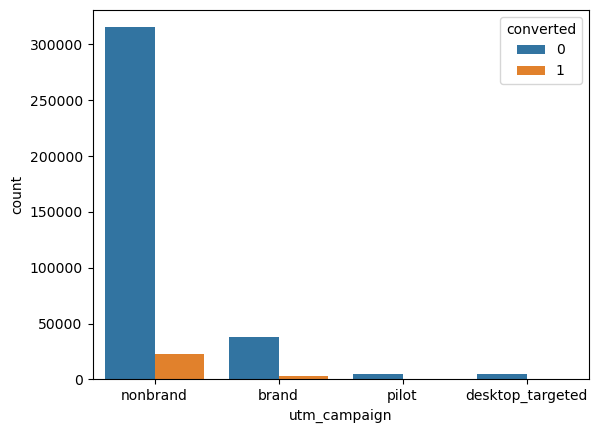

In [14]:
sns.countplot(data = source_df,x = 'utm_campaign',hue = 'converted')

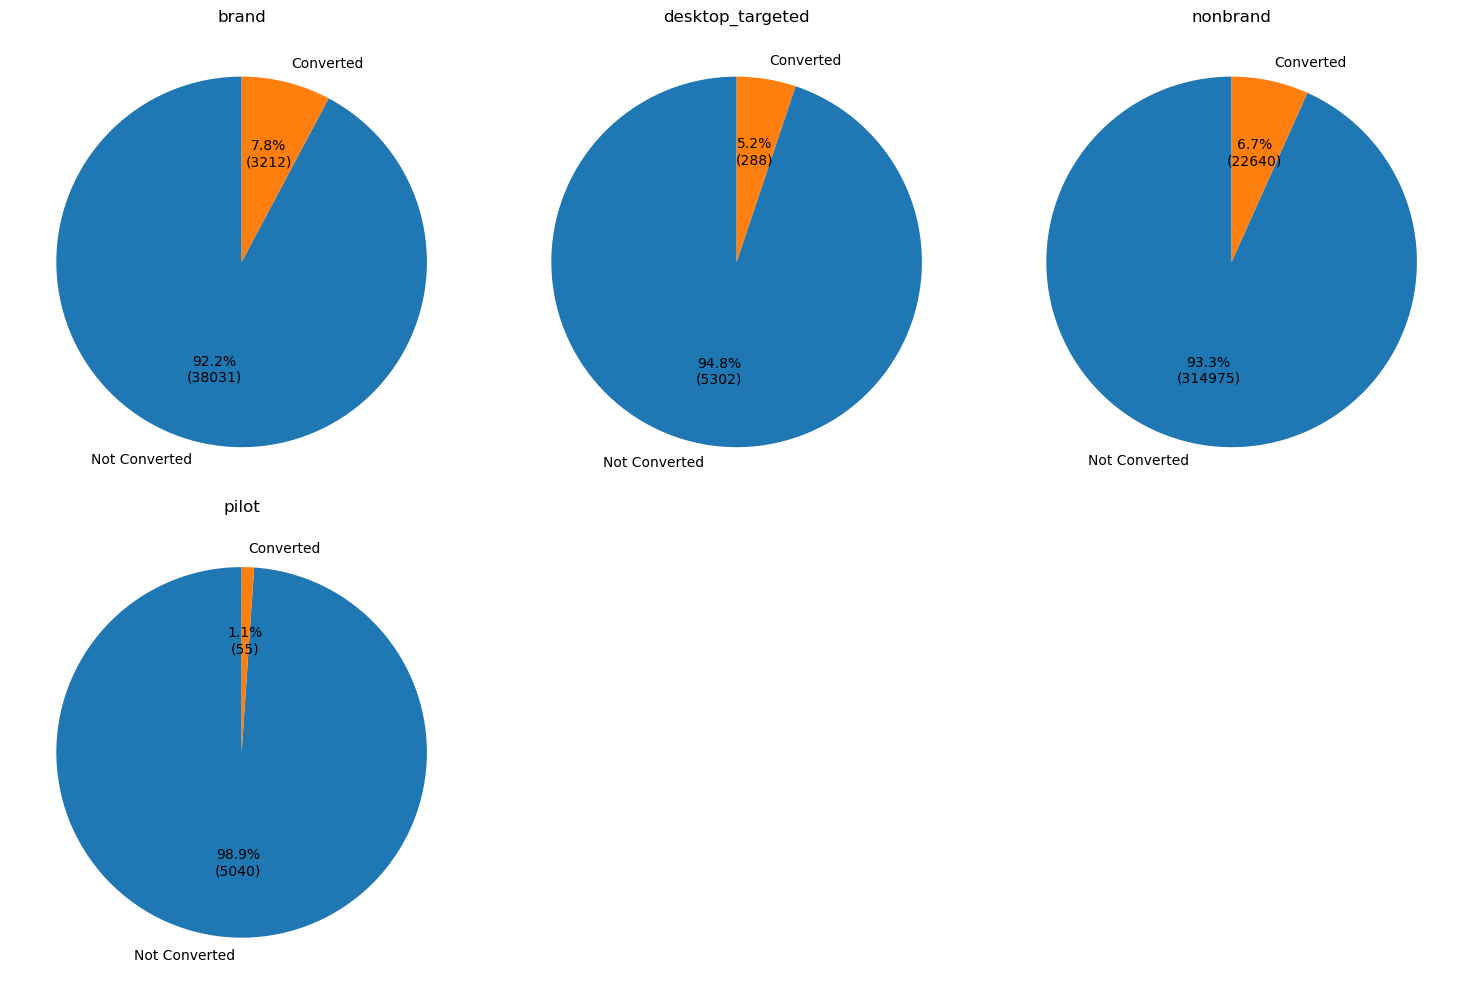

In [15]:
#Converting into pie charts to have a better look and compare them easily.
campaign_conversion = source_df.groupby(
    ['utm_campaign', 'converted']
).size().reset_index(name='count')

campaigns = campaign_conversion['utm_campaign'].dropna().unique()

fig, axes = plt.subplots(
    nrows=(len(campaigns) + 2) // 3,
    ncols=3,
    figsize=(15, 10)
)

axes = axes.flatten()

for i, campaign in enumerate(campaigns):
    data = campaign_conversion[
        campaign_conversion['utm_campaign'] == campaign
    ]

    axes[i].pie(
    data['count'],
    labels=data['converted'].map({
        0: 'Not Converted',
        1: 'Converted'
    }),
    autopct=lambda p: f'{p:.1f}%\n({p * data["count"].sum() / 100:.0f})',
    startangle=90
)
    axes[i].set_title(campaign)

# Hide unused subplots
for i in range(len(campaigns), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Maximum traffic (41243) has come from branded searches that is users searching for the specific brands on internet.It also has highest  conversion rates (7.8%),3212 converted.
* Second highest traffic (337615) has come from non branded searches that is users searching for the products without searching for our specific brand. It has a conversion rate of 6.7%, with 22640 converted.
* Third highest traffic (5590) has come from desktop targeted campaigns with a lower conversion rate of 5.2% compared to branded and non branded searches, with 288 converted.
* Pilot campaign generated 5095 sessions, but had the lowest conversion rate of 1.1%, with only 55 sessions resulting in conversions.

## We will now analyze data is distributed based between utm_campaigns and utm_sources.

<Axes: xlabel='utm_campaign', ylabel='count'>

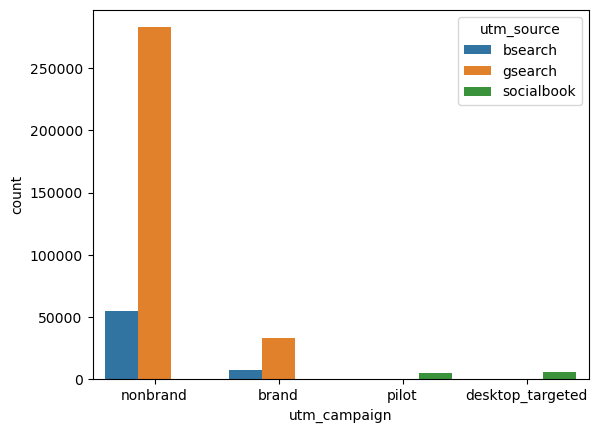

In [20]:
sns.countplot(data = session_conversion,x = 'utm_campaign',hue = 'utm_source')

In [22]:
#Verifying the numbers to understand distribution of data between utm_campaigns and utm_source since it seems specific utm_contents are part of specific campaigns only
session_conversion[['utm_campaign','utm_source']].value_counts()

utm_campaign      utm_source
nonbrand          gsearch       282706
                  bsearch        54909
brand             gsearch        33329
                  bsearch         7914
desktop_targeted  socialbook      5590
pilot             socialbook      5095
Name: count, dtype: int64

* Non brand traffic has come specifically from search engines gsearch and bsearch.
* Brand traffic has come specifically from search engines gsearch and bsearch.
* Desktop_generated traffic has been tracked only for the socialbook social media indicating the campaign was socialbook specific.
* pilot also generated traffic only through socialbook indicating campaign was socialbook specifc

In [ ]:
# Finding the counts to validate the countplot labellings
session_conversion.groupby(['device_type', 'converted']).count()

website_session_id  user_id  created_at  utm_source  \
device_type converted                                                        
desktop     0                      299222   299222      299222      252748   
            1                       27805    27805       27805       22703   
mobile      0                      141336   141336      141336      110600   
            1                        4508     4508        4508        3492   

                       utm_campaign  utm_content  is_repeat_session  
device_type converted                                                
desktop     0                252748       252748             299222  
            1                 22703        22703              27805  
mobile      0                110600       110600             141336  
            1                  3492         3492               4508

In [ ]:
pd.crosstab(index = session_conversion['device_type'],columns = session_conversion['converted'],margins = 'All')

converted,0,1,All
device_type,,,
desktop,299222,27805,327027
mobile,141336,4508,145844
All,440558,32313,472871


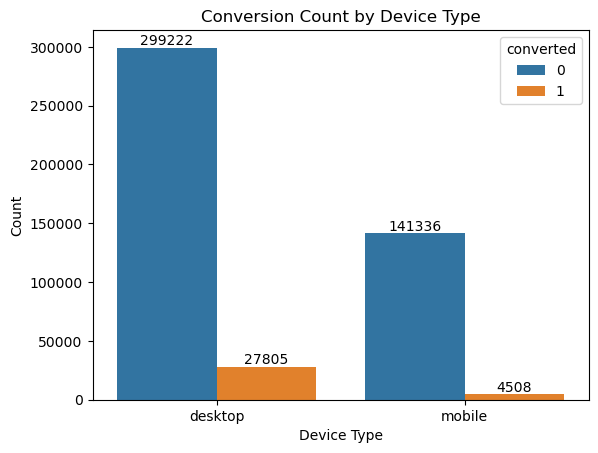

In [ ]:
#Confirmed and validated the countplot labels match the actual values as well.
ax = sns.countplot(data=session_conversion, x='device_type', hue='converted')

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 5,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )

plt.title('Conversion Count by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.show()

* More website sessions are generated from desktop compared to mobile.
* More orders are also placed via desktop compared to mobile however it could be due higher volume of traffic acquired hence hypothesis testing required to establish if device type and conversion is associated or not.

In [ ]:
#Checked that the scenario clears the assumptions of chisquared.
pvalue2 = chi2_contingency(pd.crosstab(session_conversion['device_type'], session_conversion['converted']))[1]

In [ ]:
chi2_contingency(pd.crosstab(session_conversion['device_type'], session_conversion['converted']))

Chi2ContingencyResult(statistic=np.float64(4638.433375968806), pvalue=np.float64(0.0), dof=1, expected_freq=array([[304680.05241599,  22346.94758401],
       [135877.94758401,   9966.05241599]]))

In [ ]:
if pvalue2 < 0.05:
    print("Reject the null hypothesis: There is a significant association between device_type and conversion.")

Reject the null hypothesis: There is a significant association between device_type and conversion.


## It is  discovered that device type and conversion rates are actually associated with conversion rates it would be a better idea to determine which ones the business should focus on
1) Which traffic sources contribute the most converted sessions?
2) Which traffic sources have the highest conversion rates?
3) Which high-volume traffic sources have relatively low conversion rates and therefore potential for improvement?
4) Are there low-volume traffic sources with relatively high conversion rates that may warrant further investigation? 


In [ ]:
sns.countplot(data = )